# SI 618 Homework 5 - Natural Language Processing

### The total score for this assignment will be 100 points, consisting of:
- 10 pt: Overall quality of spelling, grammar, punctuation, etc. of written sentences.
- 10 pt: Code is written in [PEP 8](https://www.python.org/dev/peps/pep-0008/) style.
- 80 pt: Homework questions. Questions 1 through 6 are worth 10 points each; Question 7 is worth 20 points.

Version 2024.02.20.CT

## Background

https://www.kaggle.com/headsortails/us-election-2020-presidential-debates

The US 2020 election saw the incumbent Republican president Donald Trump facing off against his Democrat challenger Joe Biden. Both candidates agreed to debate their political stances in the lead-up to the vote on November 3rd.

The 1st debate took place on September 29th at Case Western Reserve University in Cleveland, Ohio. It was moderated by Fox News anchor Chris Wallace. 

After Donald Trump tested positive for Covid-19 after his first debate and subsequently recovered, the 2nd presidential debate was initially converted into a virtual event. However, Trump declined to participate in a virtual debate and the event was transformed into a (socially distanced) town hall with Joe Biden alone. This event was moderated by George Stephanopoulos on the ABC network and took place on October 15th. Donald Trump then decided to hold a town hall of his own, which took place at the same day and time as the Biden town hall and was aired on NBC. This event was moderated by Savannah Guthrie.

The actual 2nd, and final, presidential debate between Biden and Trump took place on October 22nd at Belmont University, Nashville, Tennessee and was moderated by NBC News' Kristen Welker. This debate implemented stricter conditions on the candidates' speaking times to limit the frequent interruptions that had characterised the 1st debate.

The goal of this homework assignment is to investigate the transcripts of those events.

The data files are available via https://github.com/umsi-data-science/data/tree/main/us_election_2020.  Note that each file is available in two formats: CSV and TXT. You can work from either format -- the content of the corresponding CSV and TXT files is the same.

You can either use the correct URLs to the Raw version of the data files like we've done with other data files in the course so far, you can clone the repo if you're comfortable with ```git```, or you can click on each file and then view the "Raw" format and download the resulting file.  You do not need the us_election_2020_vice_presidential_debate files as we are only concerned with the presidential debates and town halls for this assignment.

Note that *you* will need to make decisions about how you
proceed with the analysis.  For example, you will need to 
decide whether you include or omit stopwords, whether you stem or lemmatize words before analysis, and how you handle weird situations.

You will need to decide when to exclude speech from the moderators and when to include it (note that in most cases, the assignment asks about the candidates, which means Trump and Biden and not the moderators).

Please fill in your uniqname in the next code cell:

In [1]:
MY_UNIQNAME = "kwasmer"

In [2]:
from collections import Counter
import contractions
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import random
import re
import seaborn as sns
import spacy
from spacy.lang.en.stop_words import STOP_WORDS
from spacy.tokens import Doc 
import statsmodels.formula.api as smf
import string 
from wordcloud import WordCloud

Answer each of the questions below.  You are encouraged to use as many code and markdown cells as you need for each question.

We **strongly** suggest running all cells from top to bottom before you submit your notebook.

## Q1.

### How many words did each candidate (Trump & Biden) use in each debate?

In [3]:
nlp = spacy.load('en_core_web_sm')

In [4]:
# Read in the csv files of the first and second presidential debates (files renamed for 
# simplicity's sake).
debate1 = pd.read_csv("2020_1st_debate.csv")
debate2 = pd.read_csv("2020_2nd_debate.csv")

In [5]:
debate1["speaker"].value_counts() # Extract the names of the speakers. 

speaker
President Donald J. Trump    314
Vice President Joe Biden     249
Chris Wallace                225
Chris Wallace:                 1
Name: count, dtype: int64

In [6]:
debate2["speaker"].value_counts() # Extract the names of the speakers. 

speaker
Donald Trump      190
Kristen Welker    189
Joe Biden         133
Name: count, dtype: int64

In [7]:
def subset_by_candidate_per_event(candidate: str, event: pd.DataFrame) -> pd.DataFrame:
    """This function quickly subsets the data frame based on the speaker. In this data set, 
    we are only looking at the quotes from Trump and Biden, but this function is intended
    to be dynamic for other natural language processing endeavors.

    Keyword arguments: 
    candidate--The presidential candidate from the 2020 debate. In this the two candidates 
    were Trump and Biden, so this function searches for any speaker rows that contain their 
    names. 

    event--This represents the candidate event. There were 2 presidential debates in 2020 
    and a town hall for each candidate.
    """
    return event[event["speaker"].str.contains(candidate)]

In [8]:
def convert_text_to_paragraph(dataset: pd.DataFrame) -> str:
    """This function converts the text column of a pandas data frame into a concatenated 
    paragraph of text. This is necessary in order to perform NLP on the text in question. 

    Keyword arguments:
    dataset--a data frame consisting of a presidential event (debate, town hall, etc.), with 
    columns consisting of the speaker, the time stamp, and the text. In some cases, the 
    data frame will have already been filtered to include the quotes of a single speaker. 
    """
    paragraph = dataset["text"].str.cat(sep=" ")
    return paragraph 

### Remove contractions from the text.

In [9]:
def remove_contractions(text: str) -> str:
    """For natural language processing, contractions can be a barrier in analyzing every 
    single word of the text. For this reason, we want to expand the contractions into an 
    easier, more analyzable way. 

    Keyword arguments:
    text--The block of text that we want to remove contractions for. Since this function 
    involves adding words via a for loop, when it comes across a word with contractions
    (e.g., I'll, isn't, etc.), it will separate it into the base words (e.g., I will, is not, etc.).
    """
    expanded_text = [] 
    for word in text.split():
        expanded_text.append(contractions.fix(word))
    return ' '.join(expanded_text)

### Remove punctuation from the text.

In [10]:
def remove_punctuation(text: str) -> str:
    """This function removes punctuation from every word in the read-in text, 
    so that the NLP only processes the word itself and not any additional characters. 

    Keyword arguments:
    text--The block of text that we want to remove punctuation for. 
    """
    return re.sub(r'[^\w\s]+', ' ', text)

### Remove stopwords from the text

In [11]:
def remove_stopwords(words: str) -> str:
    """In order to perform an accurate analysis of a piece of text, we only 
    want to look at the relevant words. Simple words such as 'a', 'and', 'the', etc. 
    provide very little information for an NLP analysis. These are known as stopwords. 
    This function removes those stopwords. 

    Keyword arguments:
    words--The block of text that we want to remove stopwords for. 
    """
    words_no_stopwords = list()
    for word in words.split():
        if word not in STOP_WORDS:
            words_no_stopwords.append(word)
    return ' '.join(words_no_stopwords)

### Lemmatization of the text

In [12]:
def lemmatize_text(text: str) -> str: 
    """To further narrow our analysis, we only want to look at the least marked form 
    of a word. This function uses the lemma token to accomplish this task. 

    Keyword arguments:
    text--The block of text which we want to lemmatize all words for. 
    """
    doc = nlp(text)
    # The code snippet below was borrowed and modified from GeeksForGeeks' article 
    # on lemmatization in Python. 
    lemmatized_sentence = " ".join([token.lemma_ for token in doc]) 
    return lemmatized_sentence

In [13]:
def get_total_word_count(text: str) -> int:
    """This function returns the total number of words in a phrase. 

    Keyword arguments:
    text--The block of text that we want to get the total word count for. 
    """
    total_words = []
    doc = nlp(text)
    for token in doc:
        if not token.is_space:
            total_words.append(token.text.lower())
    return len(total_words)

In [14]:
# This algorithm was written with the help of Github Copilot. 
def get_unique_word_count(text: str) -> int:
    """This function returns the unqiue number of words in a phrase, which is 
    denoted by the set() method in Python. 

    Keyword arguments:
    text--The block of text that we want to get the total word count for. 
    """
    unique_words = set() 
    doc = nlp(text)
    for token in doc:
        if not token.is_space:
            unique_words.add(token.text.lower())
    return len(unique_words)

In [15]:
def clean_text(text: str) -> str:
    """This function integrates all of the previous functions in order to 
    return a proper block of text that can be effectively analyzed with 
    NLP. 

    Keyword arguments: 
    text--The block of text that we want to clean and prepare for 
    natural language processing. 
    """
    text = convert_text_to_paragraph(text)
    text = remove_contractions(text)
    text = remove_punctuation(text)
    text = remove_stopwords(text)
    text = lemmatize_text(text)
    return text

In [16]:
# Create 4 different subsets for the candidates and debates that can be used in future problems.
# (This list comprehension was written with the help of Github Copilot.)
biden_d1, biden_d2, trump_d1, trump_d2 = [subset_by_candidate_per_event(candidate, debate) \
                                          for candidate in ["Biden", "Trump"] for debate in \
                                          [debate1, debate2]]

In [17]:
# Clean the text for all of the subsets to prepare for NLP. 
biden_d1_cleaned = clean_text(biden_d1)
trump_d1_cleaned = clean_text(trump_d1)
biden_d2_cleaned = clean_text(biden_d2)
trump_d2_cleaned = clean_text(trump_d2)

In [18]:
print("Biden D1 (total): " + str(get_total_word_count(biden_d1_cleaned)))
print("Trump D1 (total): " + str(get_total_word_count(trump_d1_cleaned)))
print("Biden D2 (total): " + str(get_total_word_count(biden_d2_cleaned)))
print("Trump D2 (total): " + str(get_total_word_count(trump_d2_cleaned)))

Biden D1 (total): 3202
Trump D1 (total): 3570
Biden D2 (total): 3439
Trump D2 (total): 3730


----------------
**Analysis**: For this question, I analyzed the overall word count per candidate for each debate. Although there are only two events to compare, I found it telling that Trump's word count was roughly 300 greater than Biden's. The backgrounds of each candidate could explain this discrepancy. Trump was a prominent businessman for decades and was very close with many celebrities. Someone interested in this career path is likely more talkative and extraverted. Biden struggled with a stutter as a child, but it's uncertain how much it impacted him in his adulthood. Some people have questioned if he suffers from dementia, which is quite likely considering his elderly age and showing symptoms of word salad. Two data points are not effective enough to make a definitive conclusion, but they can indicate potential trends worthy of future analysis. 

## 2. How many turns speaking did each candidate (Trump & Biden) take during each of the debates?

A "turn" is an uninterrupted period of speech.  For example, consider the following exchange:

>Chris: Big data is really interesting.

>Colleague: Actually, it's a bit boring.

>Chris: Really? Why would you say that?

>Colleague: Your choice of tools is really limited.

>Colleague: I mean, you're basically stuck with Spark, right?

>Chris: Yeah, but Spark provides most of the functionality you need to do really cool data science work.

In it, Chris had 3 turns, while his colleague had 2.

You answer should include a dataframe that looks like (with the real values instead of $__$:

<div>
<style scoped="">
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>First Debate</th>
      <th>Second Debate</th>
    </tr>
    <tr>
      <th>Candidate</th>
      <th></th>
      <th></th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>Trump</th>
      <td>__</td>
      <td>__</td>
    </tr>
    <tr>
      <th>Biden</th>
      <td>__</td>
      <td>__</td>
    </tr>
  </tbody>
</table>
</div>

In [19]:
debate1_filtered = debate1[debate1["speaker"].str.contains("Trump") | \
                           debate1["speaker"].str.contains("Biden")]

In [20]:
debate1_filtered.head() # Verify that the filter did what it was supposed to. 

,speaker,minute,text
2,Vice President Joe Biden,02:49,"How you doing, man?"
3,President Donald J. Trump,02:51,How are you doing?
4,Vice President Joe Biden,02:51,I’m well.
6,President Donald J. Trump,04:01,"Thank you very much, Chris. I will tell you ve..."
7,President Donald J. Trump,04:53,And we won the election and therefore we have ...


In [21]:
# Source: https://stackoverflow.com/questions/64481889/remove-neighbouring-duplicates-in-a-sorted-dataframe
debate1_no_adj = debate1_filtered[debate1_filtered.speaker != debate1_filtered.speaker.shift(1)]

In [22]:
debate1_no_adj.head() # Verify that each has a different speaker.

,speaker,minute,text
2,Vice President Joe Biden,02:49,"How you doing, man?"
3,President Donald J. Trump,02:51,How are you doing?
4,Vice President Joe Biden,02:51,I’m well.
6,President Donald J. Trump,04:01,"Thank you very much, Chris. I will tell you ve..."
9,Vice President Joe Biden,05:29,"Well, first of all, thank you for doing this a..."


In [23]:
debate2_filtered = debate2[debate2["speaker"].str.contains("Trump") | \
                           debate2["speaker"].str.contains("Biden")]

In [24]:
debate2_no_adj = debate2_filtered[debate2_filtered.speaker != debate2_filtered.speaker.shift(1)]
debate2_no_adj

,speaker,minute,text
1,Donald Trump,07:37,How are you doing? How are you?
9,Joe Biden,11:13,"220,000 Americans dead. You hear nothing else ..."
14,Donald Trump,13:13,"No, it’s not a guarantee, but it will be by th..."
20,Joe Biden,14:26,Make sure it’s totally transparent. Have the s...
22,Donald Trump,14:56,I don’t think we’re going to have a dark winte...
...,...,...,...
495,Joe Biden,24:07,"He takes everything out of context, but the po..."
497,Donald Trump,24:22,Is he going to get China to do it?
501,Joe Biden,24:25,"No, I’m going to rejoin Paris Accord and make ..."
502,Donald Trump,24:30,[Crosstalk 00:24:31].


In [25]:
data = {'First Debate': [201, 201],
        'Second Debate': [92, 92]}

In [26]:
df_turns = pd.DataFrame(data, index=['Trump', 'Biden'])
df_turns

,First Debate,Second Debate
Trump,201,92
Biden,201,92


----------------
**Analysis**: I computed the number of turns per candidate for each debate by dividing the number of rows in the manipulated data frames by 2, since both of them had an even row count. The sharp decrease of turns from the first debate to the second debate stood out to me. The former was notoriously comprised of petulant arguments coming from both candidates, so they interrupted each other often. Due to this controversial debate, the second debate was highly moderated. Therefore, it makes sense as to why the number of turns dropped by half. 

## 3. How many different nouns did each candidate (Trump & Biden) use in each of the debates?  

Present your results using a visualization (hint: a simple bar chart, with one bar per candidate per debate would be a good choice; you should decide whether you want to somehow stack or group the bars in your bar chart, or just leave them all side by side). You do not need to report **which** nouns were used.  Provide a written interpretation of your visualization.

In [27]:
def get_unique_nouns(text: str) -> int:
    """This function reads in a block of text and returns the count of unique nouns. 

    Keyword arguments: 
    text--The text that we want to extract the unique count of nouns from. 
    """
    unique_nouns = set() 
    doc = nlp(text)
    for token in doc:
        if token.pos_ == 'NOUN':
            unique_nouns.add(token.text.lower())
    return len(unique_nouns)

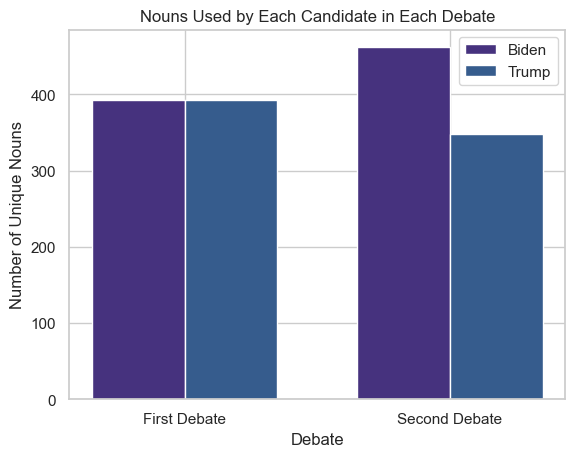

In [28]:
# Create a side-by-side bar plot of the number of unique nouns for each candidate in each debate.
# (This was written with the help of Github Copilot.)
sns.set_theme(style="whitegrid", palette="viridis")
fig, ax = plt.subplots()
bar_width = 0.35
index = np.arange(2)
biden_nouns = [get_unique_nouns(biden_d1_cleaned), get_unique_nouns(biden_d2_cleaned)]
trump_nouns = [get_unique_nouns(biden_d1_cleaned), get_unique_nouns(trump_d2_cleaned)]
biden_bar = ax.bar(index, biden_nouns, bar_width, label='Biden')
trump_bar = ax.bar(index + bar_width, trump_nouns, bar_width, label='Trump')
ax.set_xlabel('Debate')
ax.set_ylabel('Number of Unique Nouns')
ax.set_title('Nouns Used by Each Candidate in Each Debate')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(['First Debate', 'Second Debate'])
ax.legend()
plt.show()

----------------
**Analysis**: During the first debate, Trump and Biden used roughly the same number of unique nouns. However, Biden's count increased during the second debate, while Trump's decreased. Due to the chaos of the first debate, the campaign teams for each candidate probably took action and helped them to improve their technique. The `debate2_no_adj` data frame from Problem 2 provides snippets of the language used in the second debate. Based on these excerpts, Biden seemed more focused on discussing pressing issues such as the Paris Accord and the COVID-19 pandemic. At the beginning of the debate, his strategy appeared to work. Unfortunately, the second debate devolved into ad-hominem attacks once again. This explains why the noun count only changed by roughly 50 words for both candidates; there was a slight improvement, but not by much. 

## 4. Report the type-token ratio for each of the candidates (Trump & Biden), based on pooling the data from the two debates, and interpret the differences between the two candidates.

In text analysis, a 'type' is a unique word, whereas a 'token' is any word.  For example, the sentence

"One fish, two fish, red fish, blue fish"

contains 8 tokens, but 5 types (one, two, red, blue, fish).

Interestingly, the type-token ratio can be used to monitor changes in the use of vocabulary items in children with under-developed vocabulary and/or word finding difficulties and, for example, in adults who have suffered a stroke and who consequently exhibit word retrieval difficulties and naming difficulties. [Ref](https://www.sltinfo.com/type-token-ratio/)

In [29]:
def get_type_token_ratio(text: str) -> float:
    """This function calculates the type-token ratio (TTR), which returns the 
    quotient of the unique word count (i.e, the total amount of types) divided by the total 
    word count (i.e, tokens). 

    Keyword arguments: 
    text--The piece of text that we want to compute the TTR for. 
    """
    ratio = get_unique_word_count(text)/get_total_word_count(text)
    return ratio

In [30]:
print("Biden (D1): " + str(get_type_token_ratio(biden_d1_cleaned)))
print("Trump (D1): " + str(get_type_token_ratio(trump_d1_cleaned)))
print("Biden (D2): " + str(get_type_token_ratio(biden_d2_cleaned)))
print("Trump (D2): " + str(get_type_token_ratio(trump_d2_cleaned)))

Biden (D1): 0.2901311680199875
Trump (D1): 0.24649859943977592
Biden (D2): 0.29776097702820586
Trump (D2): 0.2418230563002681


In [31]:
# Compute the differences in TTR for each debate 
print(get_type_token_ratio(biden_d2_cleaned) - get_type_token_ratio(biden_d1_cleaned))
print(get_type_token_ratio(trump_d2_cleaned) - get_type_token_ratio(trump_d1_cleaned))

0.007629809008218358
-0.004675543139507826


----------------
**Analysis**: Biden and Trump had a consistent type-token ratio for both debates, which demonstrates the accuracy of the TTR. One observation I made was that Biden's TTR increased by 0.008 points, while Trump's decreased by 0.005. This correlates with the slight increase in Biden's noun count and the slight decrease in Trump's noun count during the second debate. This could be an explanation for this minor change, but it is important to remember that there could be other confounding factors. It may be worth performing a multiple regression on numerous components of the speech to see which factors impact the TTR the most. In general, however, these TTR values are quite low. This ratio is very concerning for two presidential candidates. People want a strong, well-spoken leader, and the data does not show this to be true for either candidate. 

## 5. Compare the use of named entities by the candidates (Trump & Biden) in their town hall meetings.  What patterns, if any, do you see?  

spaCy supports the following Named Entity types:
PERSON, NORP (nationalities, religious and political groups), FAC (buildings, airports etc.), ORG (organizations), GPE (countries, cities etc.), LOC (mountain ranges, water bodies etc.), PRODUCT (products), EVENT (event names), WORK_OF_ART (books, song titles), LAW (legal document titles), LANGUAGE (named languages), DATE, TIME, PERCENT, MONEY, QUANTITY, ORDINAL and CARDINAL.

You might want to use some visualization techniques to support your claims.

In [32]:
biden_town_hall = pd.read_csv("2020_townhall_jrb.csv")
biden_town_hall.head()

,speaker,minute,text
0,George Stephanopoulos,00:41,"Hey, and welcome to our town hall with Joe Bid..."
1,Joe Biden,00:46,Good to be with you.
2,George Stephanopoulos,00:47,We’re here with a group of Pennsylvania voters...
3,Joe Biden,01:02,Okay.
4,George Stephanopoulos,01:02,"And we’re going to start with Nicholas Fed, an..."


In [33]:
trump_town_hall = pd.read_csv("2020_townhall_djt.csv")
trump_town_hall.head()

,speaker,minute,text
0,Savannah Guthrie,03:50,"It’s nothing but noise. What? Okay. All right,..."
1,Speaker 1,04:35,This is an NBC news special presentation of To...
2,Savannah Guthrie,04:40,"Tonight, Donald Trump in the arena. His first ..."
3,President Trump,04:48,"I’m feeling great, I don’t know about you. How..."
4,Savannah Guthrie,04:51,"With tonight’s debate canceled, the President ..."


In [34]:
biden_th_speech = subset_by_candidate_per_event("Biden", biden_town_hall)
biden_th_speech

,speaker,minute,text
1,Joe Biden,00:46,Good to be with you.
3,Joe Biden,01:02,Okay.
5,Joe Biden,01:08,I know it well.
8,Joe Biden,01:55,"Well, first of all, going back, the fact is th..."
9,Joe Biden,02:16,"I suggested that we should be seeking, and I d..."
...,...,...,...
212,Joe Biden,01:24:26,"Every single solitary generation, the dial has..."
214,Joe Biden,01:25:10,We’d better be able to do it again.
216,Joe Biden,01:25:16,"Well, it could say I’m a lousy candidate, and ..."
218,Joe Biden,01:30:49,"Yeah. And by the way, before I came up here, I..."


In [35]:
trump_th_speech = subset_by_candidate_per_event("Trump", trump_town_hall)

In [36]:
biden_town_hall_cleaned = clean_text(biden_th_speech)
trump_town_hall_cleaned = clean_text(trump_th_speech)

In [37]:
biden_doc = nlp(biden_town_hall_cleaned)
labels = [(x.label_,x.text) for x in biden_doc.ents]
Counter(labels)

Counter({('PERSON', 'George'): 9,
         ('ORG', 'Trump'): 6,
         ('ORG', 'Senate'): 5,
         ('GPE', 'America'): 5,
         ('NORP', 'republican'): 5,
         ('LAW', 'Constitution'): 5,
         ('GPE', 'Delaware'): 5,
         ('NORP', 'Republicans'): 4,
         ('NORP', 'american'): 4,
         ('CARDINAL', 'zero'): 4,
         ('DATE', 'March'): 3,
         ('ORG', 'Congress'): 3,
         ('NORP', 'Democrats'): 3,
         ('CARDINAL', 'million'): 3,
         ('CARDINAL', '10'): 3,
         ('CARDINAL', 'one'): 3,
         ('MONEY', 'billion dollar'): 3,
         ('DATE', 'year'): 3,
         ('ORDINAL', 'second'): 3,
         ('DATE', 'day'): 3,
         ('NORP', 'Democrat'): 3,
         ('PERSON', 'Putin'): 3,
         ('DATE', 'February'): 2,
         ('GPE', 'China'): 2,
         ('CARDINAL', '44'): 2,
         ('NORP', 'Americans'): 2,
         ('ORG', 'House'): 2,
         ('CARDINAL', '00'): 2,
         ('GPE', 'United States'): 2,
         ('PERSON', 'Trump')

In [38]:
trump_doc = nlp(trump_town_hall_cleaned)
trump_labels = [(x.label_,x.text) for x in trump_doc.ents]
Counter(trump_labels)

Counter({('PERSON', 'Antifa'): 7,
         ('GPE', 'Russia'): 6,
         ('GPE', 'North Carolina'): 5,
         ('GPE', 'Savannah'): 5,
         ('NORP', 'Democrats'): 5,
         ('PERSON', 'Nancy Pelosi'): 5,
         ('NORP', 'Obamacare'): 5,
         ('GPE', 'China'): 4,
         ('PERSON', 'Joe Biden'): 4,
         ('NORP', 'Republicans'): 4,
         ('GPE', 'Ohio'): 4,
         ('GPE', 'Florida'): 3,
         ('DATE', 'today'): 3,
         ('GPE', 'Pennsylvania'): 3,
         ('LOC', 'Europe'): 3,
         ('GPE', 'UK'): 3,
         ('GPE', 'New York'): 3,
         ('PERSON', 'Biden'): 3,
         ('CARDINAL', '100'): 3,
         ('DATE', 'year'): 3,
         ('LAW', 'Roe v Wade'): 3,
         ('TIME', 'evening'): 2,
         ('ORG', 'White House'): 2,
         ('GPE', 'Virginia'): 2,
         ('GPE', 'Michigan'): 2,
         ('CARDINAL', 'thousand'): 2,
         ('PERSON', 'Dr Fauci'): 2,
         ('CARDINAL', '42'): 2,
         ('CARDINAL', '160 million'): 2,
         ('CARDI

In [39]:
# Visualize the most common entities for each candidate.
# (This was written with the help of Github Copilot.)
biden_count = [x.label_ for x in biden_doc.ents]
biden_count = Counter(biden_count)
biden_count = dict(biden_count)
biden_count = {k: v for k, v in sorted(biden_count.items(), key=lambda item: item[1], reverse=True)}
biden_count


{'CARDINAL': 67,
 'ORG': 54,
 'PERSON': 48,
 'DATE': 33,
 'GPE': 33,
 'NORP': 28,
 'MONEY': 13,
 'LAW': 9,
 'ORDINAL': 4,
 'FAC': 4,
 'LOC': 4,
 'QUANTITY': 2,
 'TIME': 2,
 'PRODUCT': 1,
 'WORK_OF_ART': 1}

In [40]:
trump_count = [x.label_ for x in trump_doc.ents]
trump_count = Counter(trump_count)
trump_count = dict(trump_count)
trump_count = {k: v for k, v in sorted(trump_count.items(), key=lambda item: item[1], reverse=True)}
trump_count

{'GPE': 51,
 'PERSON': 43,
 'CARDINAL': 35,
 'DATE': 25,
 'NORP': 20,
 'ORG': 18,
 'TIME': 3,
 'LOC': 3,
 'LAW': 3,
 'PRODUCT': 1,
 'MONEY': 1,
 'ORDINAL': 1,
 'QUANTITY': 1}

In [41]:
# Find the union of the entities used by each candidate to establish x-axes for barplot. 
union = set(biden_count.keys()) | set(trump_count.keys())
union

{'CARDINAL',
 'DATE',
 'FAC',
 'GPE',
 'LAW',
 'LOC',
 'MONEY',
 'NORP',
 'ORDINAL',
 'ORG',
 'PERSON',
 'PRODUCT',
 'QUANTITY',
 'TIME',
 'WORK_OF_ART'}

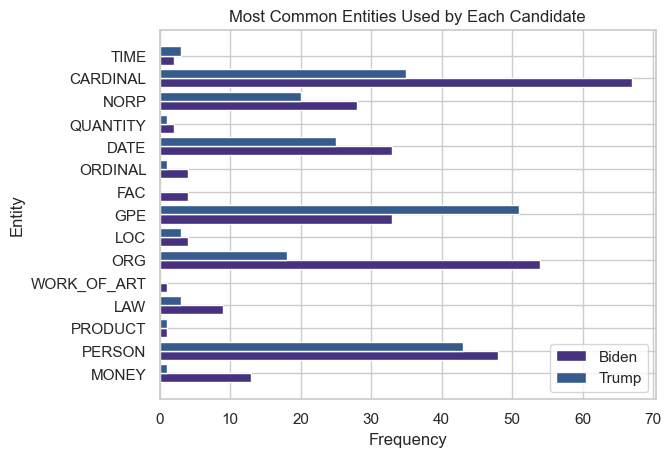

In [42]:
# This plot was written with the help of Github Copilot.
sns.set_theme(style="whitegrid", palette="viridis")
fig, ax = plt.subplots()
bar_height = .4  
index = np.arange(len(union))
biden_bar = ax.barh(index, [biden_count.get(entity, 0) for entity in union], bar_height, label='Biden')
trump_bar = ax.barh(index + bar_height, [trump_count.get(entity, 0) for entity in union], bar_height, label='Trump')
ax.set_ylabel('Entity')
ax.set_xlabel('Frequency')
ax.set_title('Most Common Entities Used by Each Candidate')
ax.set_yticks(index + bar_height / 2)
ax.set_yticklabels(union)
ax.legend()
plt.show()

----------------
**Analysis**: The visualization of the most common entities for each candidate revealed some information that surprised me. For instance, I expected more nouns from Trump in the "MONEY" and "LAW" categories, but Biden significantly outnumbered him in both. Before the debates, Trump was very obsessed with implementing stricter law enforcement policies. That being said, this visualization shows the unique entities spoken by each candidate, so he may have simply repeated common buzzwords to get his point across. Another discrepancy I found interesting was the "CARDINAL" frequency; Biden also outnumbered Trump in this area. From the excerpts in `debate2_no_adj`, Biden refers to many statistics (especially regarding COVID), while Trump had a very nonchalant and dangerous response to the virus. 

I was not surprised to see the high frequencies of "NORP", "GPE", and "PERSON". As mentioned in Problem 3, ad-hominem attacks were pervasive in both debates, so it does not surprise me that they consistenly referred to other people in their town hall speeches. 2020 was also characterized by many issues regarding race relations (e.g., the Sinophobia after COVID-19, the murder of George Floyd, etc.). Presidential candidates have a responsibility to address these issues, because voters who belong to one or more of these demographics want a candidate who can protect their community. 

Furthermore, both Trump and Biden have a tendency to support inteventionism, despite the former's claim of being "America First". Both of them have advocated for getting involved in wars that do not involve the U.S. in any capacity (e.g., Syria, Russia, Iraq, etc.). Two major talking points in the debates included the alleged Russian interference in the 2016 election, and Biden's alleged connections with China. Both candidates attacked the other for these alleged alliances. With these two factors in mind, it does not surprise me that they often discussed numerous geographical locations in their town hall speeches. 

## 6. Generate a word cloud for Trump's town hall (use only Trump's words) and one for Biden's town hall (again, use only Biden's words).  Compare and contrast the two word clouds.

Install a word cloud generating package like the one from https://github.com/amueller/word_cloud

In [43]:
def create_word_cloud(text: str, seed: int) -> None:
    """This function returns a word cloud that shows the most frequent words used 
    in a piece of text. The largers words represent a greater frequency while the 
    smaller words reprent a smaller frequency. 
    
    Keyword arguments: 
    text--This is the text that we want to generate a word cloud for. 
    seed--A number that allows the word cloud to be reproducible and initializes a 
    pseudorandom number generator. (Source: https://en.wikipedia.org/wiki/Random_seed)
    """
    random.seed(seed)
    wordcloud = WordCloud().generate(text)
    plt.imshow(wordcloud)
    plt.axis('off')
    plt.show()

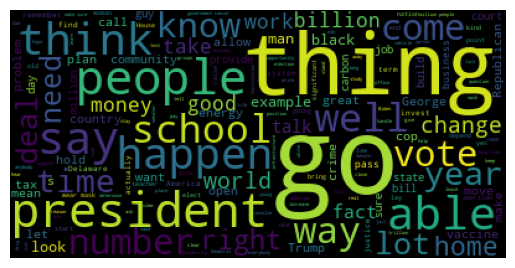

In [44]:
create_word_cloud(biden_town_hall_cleaned, 42)

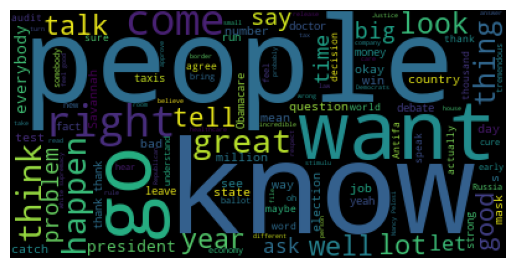

In [45]:
create_word_cloud(trump_town_hall_cleaned, 42)

----
**Analysis:** The word clouds for Biden's town hall versus Trump's town hall reveal valuable information about each candidate's campaign strategy. These visualizations also indicate their differences in rhetoric. Biden takes a middle-ground approach and wants to appeal to political moderates. He emphasizes community over division in this speech. He also highlights the importance of voting in the general election, promising change in this country. Trump's approach is more emotion-based. He uses words such as "good", "great", "big", "bad" and has a very idealistic vision of the "American Dream". 

## 7. Sentiment analysis of Trump vs. Biden in second debate

Note that you will want to review the video on Sentiment Analysis with NLTK and spaCy from the pre-recorded lectures.

Perform a sentiment analysis that compares the sentiment of the two candidates (Trump & Biden) in the second debate.  

There are several ways to do this.  In its simplest form, you could determine the sentiment for each utterance, the perform some mathematical summary (sum, mean, etc.) A slightly more elegant solution would involve tracking how sentiment changes over the course of the debate for each of the candidates.  A further extension of your work might use the [pandas.DataFrame.rolling()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.rolling.html) method to calculate rolling averages, although using that function will probably require you to also learn about [time functions in pandas](https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html).

No matter what approach you choose, you should be sure to use visualizations in your answer.  As always, provide an interpretation of your results, including any visualizations (i.e. don't just provide a visualization, explain what's interesting that you see in your visualizations).

In [46]:
sent_analyzer = SentimentIntensityAnalyzer()
def sentiment_scores(docx):
    return sent_analyzer.polarity_scores(docx.text)

In [47]:
Doc.set_extension("sentimenter",getter=sentiment_scores)

In [48]:
biden_d2

,speaker,minute,text
9,Joe Biden,11:13,"220,000 Americans dead. You hear nothing else ..."
10,Joe Biden,11:56,"The expectation is we’ll have another 200,000 ..."
11,Joe Biden,12:19,What I would do is make sure we have everyone ...
12,Joe Biden,12:41,We’re in a situation now where the New England...
20,Joe Biden,14:26,Make sure it’s totally transparent. Have the s...
...,...,...,...
495,Joe Biden,24:07,"He takes everything out of context, but the po..."
501,Joe Biden,24:25,"No, I’m going to rejoin Paris Accord and make ..."
508,Joe Biden,25:57,"I will say, I’m an American President. I repre..."
509,Joe Biden,26:19,"We can grow this economy, we can deal with the..."


In [49]:
trump_d2

,speaker,minute,text
1,Donald Trump,07:37,How are you doing? How are you?
5,Donald Trump,09:04,"So as you know, 2.2 million people modeled out..."
6,Donald Trump,09:41,There was a very big spike in Texas. It’s now ...
7,Donald Trump,10:04,"I can tell you from personal experience, I was..."
14,Donald Trump,13:13,"No, it’s not a guarantee, but it will be by th..."
...,...,...,...
499,Donald Trump,24:23,Is he going to get China to do it?
502,Donald Trump,24:30,[Crosstalk 00:24:31].
504,Donald Trump,24:47,We have to make our country totally successful...
505,Donald Trump,25:01,"Before the plague came in, just before, I was ..."


In [50]:
# Compute sentiment scores for each line of the debate.
# (This was written with the help of Github Copilot.)
biden_d2["sentiment"] = biden_d2.apply(lambda x: nlp(x["text"])._. \
                                       sentimenter['compound'], axis=1)
trump_d2["sentiment"] = trump_d2.apply(lambda x: nlp(x["text"])._.\
                                       sentimenter['compound'], axis=1)


/var/folders/np/r8bkr3hd3bsdsjvxgq559f0h0000gn/T/ipykernel_30281/4163711742.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  biden_d2["sentiment"] = biden_d2.apply(lambda x: nlp(x["text"])._. \
/var/folders/np/r8bkr3hd3bsdsjvxgq559f0h0000gn/T/ipykernel_30281/4163711742.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trump_d2["sentiment"] = trump_d2.apply(lambda x: nlp(x["text"])._.\


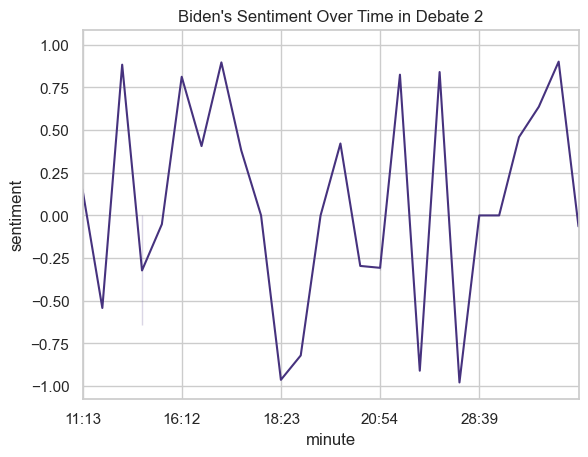

In [51]:
# Create a plot showing the change in sentiment over time for debate 2, 
# (Source: Copilot)
sns.set_theme(style="whitegrid", palette="viridis")
sns.lineplot(data=biden_d2, x="minute", y="sentiment")
plt.title("Biden's Sentiment Over Time in Debate 2")
plt.xlim(0, 25)
plt.xticks(np.arange(0, 25, 5))
plt.show()

In [52]:
trump_d2

,speaker,minute,text,sentiment
1,Donald Trump,07:37,How are you doing? How are you?,0.0000
5,Donald Trump,09:04,"So as you know, 2.2 million people modeled out...",-0.9190
6,Donald Trump,09:41,There was a very big spike in Texas. It’s now ...,0.3612
7,Donald Trump,10:04,"I can tell you from personal experience, I was...",0.5574
14,Donald Trump,13:13,"No, it’s not a guarantee, but it will be by th...",0.6736
...,...,...,...,...
499,Donald Trump,24:23,Is he going to get China to do it?,0.0000
502,Donald Trump,24:30,[Crosstalk 00:24:31].,0.0000
504,Donald Trump,24:47,We have to make our country totally successful...,0.3708
505,Donald Trump,25:01,"Before the plague came in, just before, I was ...",0.6808


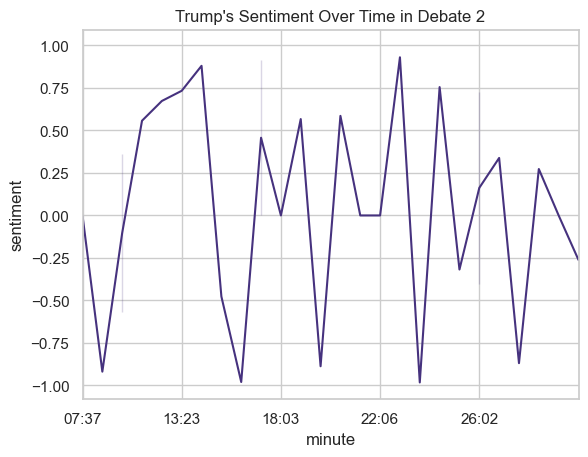

In [53]:
sns.set_theme(style="whitegrid", palette="viridis")
sns.lineplot(data=trump_d2, x="minute", y="sentiment")
plt.title("Trump's Sentiment Over Time in Debate 2")
plt.xlim(0, 25)
plt.xticks(np.arange(0, 25, 5))
plt.show()

In [54]:
biden_model = smf.ols("sentiment ~ minute", data=biden_d2)
biden_model.fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              sentiment   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.603
Method:                 Least Squares   F-statistic:                     2.540
Date:                Thu, 07 Mar 2024   Prob (F-statistic):              0.325
Time:                        12:20:10   Log-Likelihood:                 240.85
No. Observations:                 133   AIC:                            -219.7
Df Residuals:                       2   BIC:                             158.9
Df Model:                         130                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.9902      0.323      3.069      0.092      -0.398       2.378
minute[T.01:31]    -0.9902      0.456     -2.170      0.162      -2.953       0.973
minute[T.01:33]    -0.9130      0.456     -2.001      0.183      -2.876       1.050
minute[T.01:57]    -1.5534      0.456     -3.404      0.077      -3.517       0.410
minute[T.03:23]    -1.9295      0.456     -4.229      0.052      -3.893       0.034
minute[T.03:52]    -0.9902      0.456     -2.170      0.162      -2.953       0.973
minute[T.04:12]    -1.8762      0.456     -4.112      0.054      -3.839       0.087
minute[T.04:43]    -1.0929      0.456     -2.395      0.139      -3.056       0.870
minute[T.04:53]    -1.1693      0.456     -2.563      0.124      -3.133       0.794
minute[T.05:09]    -0.9902      0.456     -2.170      0.162      -2.953       0.973
minute[T.05:13]    -0.6720      0.456     -1.473      0.279      -2.635       1.291
minute[T.05:28]    -0.2323      0.456     -0.509      0.661      -2.196       1.731
minute[T.06:09]    -0.9902      0.456     -2.170      0.162      -2.953       0.973
minute[T.06:13]    -0.9902      0.456     -2.170      0.162      -2.953       0.973
minute[T.06:20]    -0.9902      0.456     -2.170      0.162      -2.953       0.973
minute[T.06:22]    -0.1095      0.456     -0.240      0.833      -2.073       1.854
minute[T.06:24]    -1.1483      0.456     -2.517      0.128      -3.112       0.815
minute[T.06:51]    -0.9902      0.456     -2.170      0.162      -2.953       0.973
minute[T.06:57]    -1.7747      0.456     -3.889      0.060      -3.738       0.189
minute[T.08:01]    -1.7481      0.456     -3.831      0.062      -3.711       0.215
minute[T.08:30]    -1.9534      0.456     -4.281      0.050      -3.917       0.010
minute[T.09:10]    -0.9902      0.456     -2.170      0.162      -2.953       0.973
minute[T.09:13]    -0.9902      0.456     -2.170      0.162      -2.953       0.973
minute[T.09:19]    -0.9902      0.456     -2.170      0.162      -2.953       0.973
minute[T.09:21]    -1.3154      0.456     -2.883      0.102      -3.279       0.648
minute[T.09:32]    -0.7170      0.456     -1.571      0.257      -2.680       1.246
minute[T.09:39]    -1.3154      0.456     -2.883      0.102      -3.279       0.648
minute[T.09:41]    -0.4494      0.456     -0.985      0.429      -2.413       1.514
minute[T.10:03]    -0.0296      0.456     -0.065      0.954      -1.993       1.934
minute[T.10:11]    -0.9708      0.456     -2.128      0.167      -2.934       0.992
minute[T.10:54]    -0.9902      0.456     -2.170      0.162      -2.953       0.973
minute[T.11:03]    -0.9902      0.456     -2.170      0.162      -2.953       0.973
minute[T.11:08]    -1.3154      0.456     -2.883      0.102      -3.279       0.648
minute[T.11:13]    -0.8384      0.456     -1.837      0.208

In [55]:
trump_model = smf.ols("sentiment ~ minute", data=trump_d2)
trump_model.fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              sentiment   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                 -0.005
Method:                 Least Squares   F-statistic:                    0.9944
Date:                Thu, 07 Mar 2024   Prob (F-statistic):              0.567
Time:                        12:20:11   Log-Likelihood:                 168.03
No. Observations:                 190   AIC:                             27.93
Df Residuals:                       8   BIC:                             618.9
Df Model:                         181                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.1779      0.487      0.365      0.724      -0.945       1.301
minute[T.00:33]    -1.0664      0.689     -1.548      0.160      -2.655       0.522
minute[T.01:15]    -1.0994      0.689     -1.596      0.149      -2.688       0.489
minute[T.02:15]     0.7808      0.689      1.134      0.290      -0.807       2.369
minute[T.02:33]     0.6316      0.689      0.917      0.386      -0.957       2.220
minute[T.02:57]     0.5570      0.689      0.809      0.442      -1.031       2.145
minute[T.03:11]    -0.0248      0.689     -0.036      0.972      -1.613       1.563
minute[T.03:23]    -0.7903      0.689     -1.148      0.284      -2.378       0.798
minute[T.04:02]    -0.2806      0.689     -0.407      0.694      -1.869       1.308
minute[T.04:08]    -0.9168      0.689     -1.331      0.220      -2.505       0.671
minute[T.04:52]    -0.1779      0.689     -0.258      0.803      -1.766       1.410
minute[T.04:53]    -0.1779      0.689     -0.258      0.803      -1.766       1.410
minute[T.05:09]    -0.2295      0.689     -0.333      0.748      -1.818       1.359
minute[T.05:10]    -0.1779      0.689     -0.258      0.803      -1.766       1.410
minute[T.05:14]    -0.7023      0.689     -1.020      0.338      -2.290       0.886
minute[T.05:52]    -0.1779      0.689     -0.258      0.803      -1.766       1.410
minute[T.05:53]    -0.1007      0.689     -0.146      0.887      -1.689       1.487
minute[T.05:55]     0.6321      0.689      0.918      0.386      -0.956       2.220
minute[T.05:58]     0.4061      0.689      0.590      0.572      -1.182       1.994
minute[T.06:10]    -0.8587      0.689     -1.247      0.248      -2.447       0.729
minute[T.06:13]    -0.8265      0.689     -1.200      0.264      -2.415       0.762
minute[T.06:44]    -0.3558      0.689     -0.517      0.619      -1.944       1.232
minute[T.06:51]    -0.1779      0.689     -0.258      0.803      -1.766       1.410
minute[T.06:56]    -0.0752      0.689     -0.109      0.916      -1.663       1.513
minute[T.07:01]    -0.1779      0.689     -0.258      0.803      -1.766       1.410
minute[T.07:24]     0.4947      0.689      0.718      0.493      -1.093       2.083
minute[T.07:25]    -0.1779      0.689     -0.258      0.803      -1.766       1.410
minute[T.07:28]    -0.1779      0.689     -0.258      0.803      -1.766       1.410
minute[T.07:29]    -1.0815      0.689     -1.570      0.155      -2.670       0.507
minute[T.07:37]    -0.1779      0.689     -0.258      0.803      -1.766       1.410
minute[T.07:58]    -0.3059      0.689     -0.444      0.669      -1.894       1.282
minute[T.08:03]     0.7116      0.689      1.033      0.332      -0.877       2.300
minute[T.08:19]     0.4345      0.689      0.631      0.546      -1.154       2.023
minute[T.08:54]     0.6581      0.689      0.956      0.367

----------------
**Analysis**: The sentiment analyses for both candidates was quite versatile in the second debate. This did not surprise me since both Trump and Biden were emotionally charged and did not seem to learn much from the first debate. That being said, it is worth noting that the extreme spikes in both visualizations could be a consequence of overfitting. The $R^{2}$ values for both of the OLS computations are around .99, which indicates a very strong coefficient of determination. However, the p-values for each predictor are statistically insignificant across the board. Looking deeper, it appears that the times were not consistent in the CSV, which could have led to these erratic results. It may be worth computing the sentiment analysis in a different way, such as grouping together the different times and finding the average compound score for each minute. 

# Please submit your notebook in .IPYNB and .HTML formats

We **strongly** suggest running all cells from top to bottom before you submit your notebook.